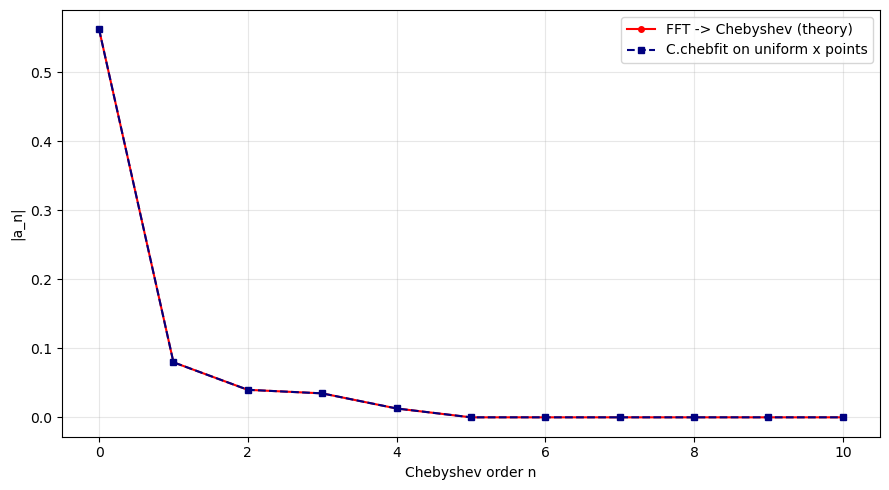

max(a_chebfit_B - a_from_fft) = 1.0075094143928853e-15


In [130]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt
import torch
from functools import reduce

np.random.seed(0)

# ==========================
# Hyperparameters
# ==========================
n_qubits = 1
L = 4
Nx_u = 512          # u-grid size for FFT (use power of 2, large enough)
Nx_fit = 80         # number of points used for chebfit
deg_max = 10
blocks    = 2


dev = qml.device("default.qubit", wires=n_qubits)

# ==========================
# QNode: input x in [-1,1], internally uses arccos(x)
# ==========================
def pauli_encoding(x, sign):
    for w in range(n_qubits):
        qml.RX(sign*x, wires=w)
        
def novel_exp_encoding(x, layer, sign):
    """
    x is assumed in [-1, 1].
    """
    eta = 3**(n_qubits*layer)
    phi = sign * np.arccos(x)
    angle1 = eta * phi * 3.0
    angle2 = eta * phi
    qml.RZ(angle1, wires=0)
    qml.RZ(angle2, wires=1)

def Observable_local(n, device='cpu', dtype=torch.float32):
    """
    Returns the operator O_L = (1/n) * sum_j (|0><0|_j ⊗ I_{rest})
    as a 2^n x 2^n tensor.
    """
    # single-qubit projectors and identity
    P0 = torch.tensor([[1., 0.],
                       [0., 0.]], device=device, dtype=dtype)
    I2 = torch.eye(2, device=device, dtype=dtype)

    # accumulate sum of tensor-products
    OL = torch.zeros((2**n, 2**n), device=device, dtype=dtype)
    for j in range(n):
        # build list of n factors: P0 at position j, I elsewhere
        factors = [P0 if k == j else I2 for k in range(n)]
        # take the n-fold Kronecker product
        op_j = reduce(lambda A, B: torch.kron(A, B), factors)
        OL += op_j

    # average
    return OL / n


O_L = Observable_local(n_qubits).numpy()

@qml.qnode(dev)
def circuit_QFM(x, weights):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        pauli_encoding(x, 1)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    # return qml.expval(qml.PauliZ(0))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))


@qml.qnode(dev)
def circuit_QCM(x, weights,sign):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        pauli_encoding(np.arccos(x), sign)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    # return qml.expval(qml.PauliZ(0))
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))

# weights = np.random.uniform(0, 2*np.pi, size=L)
weights = np.random.uniform(
    0, 2*np.pi,
    size=(L+1, blocks, n_qubits, 3)
)

# ==========================
# 1) "Ground truth" Chebyshev coefficients from FFT in u
#    using u uniform, x = cos u
# ==========================
u_grid = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
# x_from_u = np.cos(u_grid)
f_u = np.array([circuit_QFM(x, weights) for x in u_grid], dtype=float)

c_fft = np.fft.fft(f_u) / Nx_u   # complex Fourier coefficients of f(u)
# For real-valued f(u): Chebyshev coefficients of f(cos u) are
# a0 = Re(c0), an = 2 Re(cn) for n>=1
a_from_fft = np.zeros(deg_max + 1, dtype=float)
a_from_fft[0] = np.real(c_fft[0])
for n in range(1, deg_max + 1):
    a_from_fft[n] = 2.0 * np.real(c_fft[n])


# ==========================
# 2B) chebfit on uniform x grid (your "公平"直觉版本)
# ==========================
x_fit_B = np.linspace(-1.0, 1.0, Nx_fit, endpoint=True)
y_fit_B = np.array([(circuit_QCM(x, weights,1)+circuit_QCM(x, weights,-1))/2 for x in x_fit_B], dtype=float)

a_chebfit_B = C.chebfit(x_fit_B, y_fit_B, deg=deg_max)

# ==========================
# Plot: compare magnitudes
# ==========================
orders = np.arange(deg_max + 1)

plt.figure(figsize=(9,5))
plt.plot(orders, np.abs(a_from_fft), 'o-', color='red', markersize=4, label="FFT -> Chebyshev (theory)")
plt.plot(orders, np.abs(a_chebfit_B), 's--', color='navy', markersize=4, label="C.chebfit on uniform x points")
plt.xlabel("Chebyshev order n")
plt.ylabel("|a_n|")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================
# Numeric differences
# ==========================
print("max(a_chebfit_B - a_from_fft) =", np.max(a_chebfit_B - a_from_fft))


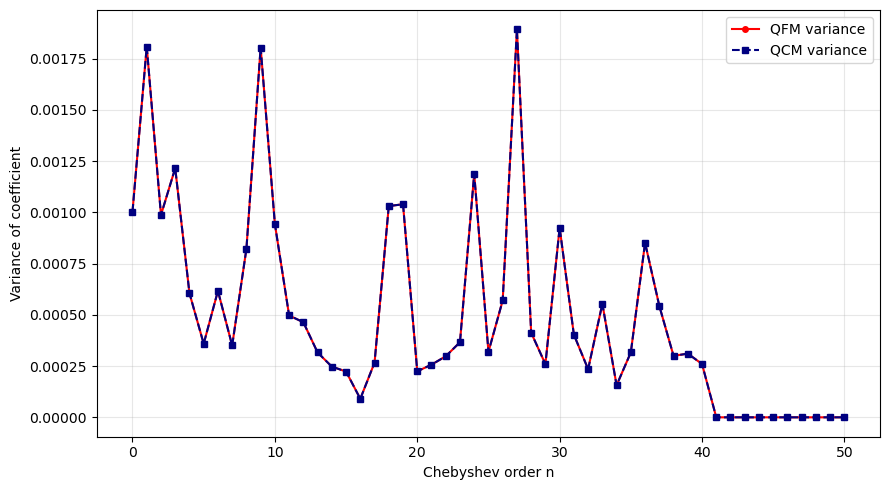

Done.


In [153]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt

np.random.seed(0)

# ==========================
# Hyperparameters
# ==========================
n_qubits = 2
L = 2
Nx_u = 200
Nx_fit = 200
deg_max = 50
blocks = 3
n_samples = 50   # Monte Carlo samples

dev = qml.device("default.qubit", wires=n_qubits)
O_L = Observable_local(n_qubits).numpy()

# ==========================
# Encodings
# ==========================
def pauli_encoding(x, sign):
    for w in range(n_qubits):
        qml.RX(sign * x, wires=w)

def novel_exp_encoding(x, layer, sign):
    """
    x is assumed in [-1, 1].
    """
    eta = 3**(n_qubits*layer)
    phi = sign * x
    angle1 = eta * phi * 3.0
    angle2 = eta * phi
    qml.RZ(angle1, wires=0)
    qml.RZ(angle2, wires=1)

@qml.qnode(dev)
def circuit_QFM(x, weights):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        # pauli_encoding(x, 1)
        novel_exp_encoding(x, l, 1)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def circuit_QCM(x, weights, sign):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        # pauli_encoding(np.arccos(x), sign)
        novel_exp_encoding(np.arccos(x), l, sign)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

# ==========================
# Storage
# ==========================
coeffs_QFM = []
coeffs_QCM = []

# ==========================
# Monte Carlo loop
# ==========================
for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    # --------------------------------
    # QFM : FFT-based Chebyshev
    # --------------------------------
    u_grid = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f_u = np.array([circuit_QFM(u, weights) for u in u_grid])

    c_fft = np.fft.fft(f_u) / Nx_u

    a_fft = np.zeros(deg_max + 1)
    a_fft[0] = np.real(c_fft[0])
    for n in range(1, deg_max + 1):
        a_fft[n] = 2 * np.real(c_fft[n])

    coeffs_QFM.append(a_fft)

    # --------------------------------
    # QCM : chebfit
    # --------------------------------
    x_grid = np.linspace(-1, 1, Nx_fit)
    y_vals = np.array([
        (circuit_QCM(x, weights, 1) +
         circuit_QCM(x, weights, -1)) / 2
        for x in x_grid
    ])

    a_cheb = C.chebfit(x_grid, y_vals, deg=deg_max)
    coeffs_QCM.append(a_cheb)

# ==========================
# Convert to arrays
# ==========================
coeffs_QFM = np.array(coeffs_QFM)
coeffs_QCM = np.array(coeffs_QCM)

# ==========================
# Compute variance
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)
var_QCM = np.var(coeffs_QCM, axis=0)

orders = np.arange(deg_max + 1)

# ==========================
# Plot
# ==========================
size = 6
cutoff = 4
var_mean = np.mean(var_QCM[:4])

plt.figure(figsize=(9,5))
plt.plot(orders, var_QFM, 'o-', color='red', markersize=4, label="QFM variance")
plt.plot(orders, var_QCM, 's--', color='navy', markersize=4, label="QCM variance")
# plt.axvline(x=cutoff, color='r', linestyle='--', alpha=0.5, label='Expected Max Freq')
# plt.axhline(y=var_mean, color='green', linestyle='--', linewidth=2, label=r'Average Var')
plt.xlabel("Chebyshev order n")
plt.ylabel("Variance of coefficient")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Done.")

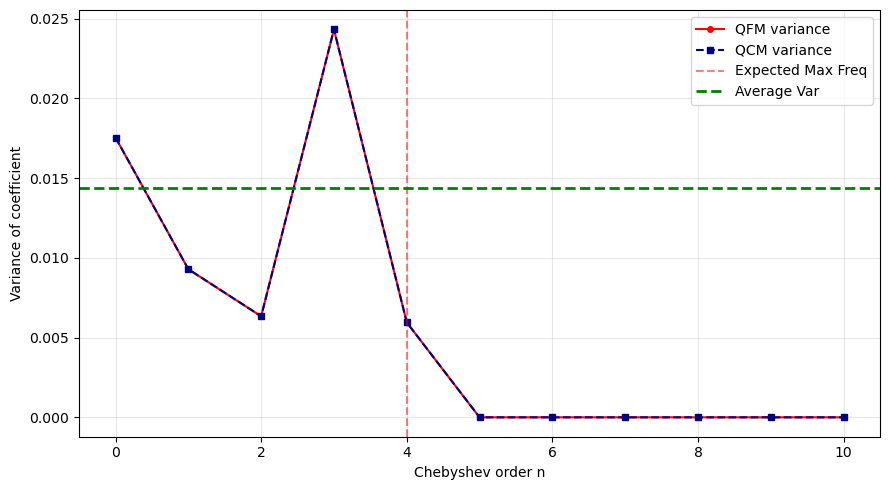

Done.


In [135]:
# ==========================
# Plot
# ==========================
size = 6
cutoff = 4
var_mean = np.mean(var_QCM[:4])

plt.figure(figsize=(9,5))
plt.plot(orders, var_QFM, 'o-', color='red', markersize=4, label="QFM variance")
plt.plot(orders, var_QCM, 's--', color='navy', markersize=4, label="QCM variance")
# plt.semilogy(orders, var_QFM, 'o-', color='red', markersize=4, label="QFM variance")
# plt.semilogy(orders, var_QCM, 's--', color='navy', markersize=4, label="QCM variance")
plt.axvline(x=cutoff, color='r', linestyle='--', alpha=0.5, label='Expected Max Freq')
plt.axhline(y=var_mean, color='green', linestyle='--', linewidth=2, label=r'Average Var')
plt.xlabel("Chebyshev order n")
plt.ylabel("Variance of coefficient")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Done.")

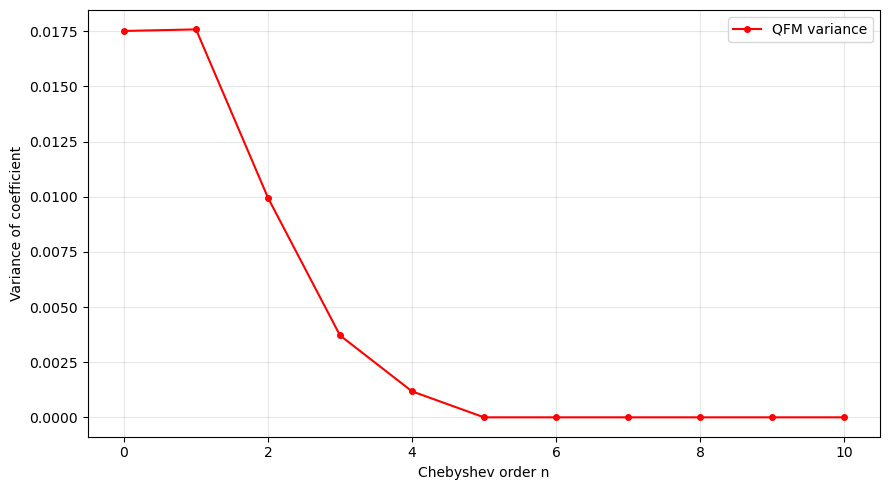

Done.


In [148]:
import numpy as np
import pennylane as qml
import numpy.polynomial.chebyshev as C
import matplotlib.pyplot as plt

np.random.seed(0)

# ==========================
# Hyperparameters
# ==========================
n_qubits = 1
L = 4
Nx_u = 20
Nx_fit = 20
deg_max = 10
blocks = 2
n_samples = 100   # Monte Carlo samples

dev = qml.device("default.qubit", wires=n_qubits)

# ==========================
# Encodings
# ==========================
def pauli_encoding(x, sign):
    for w in range(n_qubits):
        qml.RX(sign * x, wires=w)

@qml.qnode(dev)
def circuit_QFM(x, weights):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        pauli_encoding(x, 1)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def circuit_QCM(x, weights, sign):
    qml.templates.StronglyEntanglingLayers(
        weights[0], wires=range(n_qubits)
    )
    for l in range(L):
        pauli_encoding(np.arccos(x), sign)
        qml.templates.StronglyEntanglingLayers(
            weights[l+1], wires=range(n_qubits)
        )
    return qml.expval(qml.Hermitian(O_L, wires=range(n_qubits)))
    # return qml.expval(qml.PauliZ(0))

# ==========================
# Storage
# ==========================
coeffs_QFM = []
coeffs_QCM = []

# ==========================
# Monte Carlo loop
# ==========================
for sample in range(n_samples):

    weights = np.random.uniform(
        0, 2*np.pi,
        size=(L+1, blocks, n_qubits, 3)
    )

    # --------------------------------
    # QFM : FFT-based Chebyshev
    # --------------------------------
    u_grid = np.linspace(0, 2*np.pi, Nx_u, endpoint=False)
    f_u = np.array([circuit_QFM(u, weights) for u in u_grid])

    c_fft = np.fft.fft(f_u) / Nx_u

    a_fft = np.zeros(deg_max + 1, dtype=complex)
    a_fft[0] = c_fft[0]
    for n in range(1, deg_max + 1):
        a_fft[n] = c_fft[n]
    # coeffs_QFM.append(a_fft.real+1j*a_fft.imag)
    coeffs_QFM.append(a_fft)


# ==========================
# Convert to arrays
# ==========================
coeffs_QFM = np.array(coeffs_QFM)

# ==========================
# Compute variance
# ==========================
var_QFM = np.var(coeffs_QFM, axis=0)

orders = np.arange(deg_max + 1)

# ==========================
# Plot
# ==========================
size = 6
cutoff = 4
var_mean = np.mean(var_QCM[:4])

plt.figure(figsize=(9,5))
plt.plot(orders, var_QFM, 'o-', color='red', markersize=4, label="QFM variance")
# plt.plot(orders, var_QCM, 's--', color='navy', markersize=4, label="QCM variance")
# plt.axvline(x=cutoff, color='r', linestyle='--', alpha=0.5, label='Expected Max Freq')
# plt.axhline(y=var_mean, color='green', linestyle='--', linewidth=2, label=r'Average Var')
plt.xlabel("Chebyshev order n")
plt.ylabel("Variance of coefficient")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("Done.")